# EPL Match Outcome Prediction — CNN from Scratch
### 1D Convolutional Neural Network — No prebuilt ML libraries
All layers (Conv1D, Dense, BatchNorm, Dropout) implemented from scratch using only NumPy and Pandas. Matplotlib / Seaborn for visualisation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import pickle
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')

np.random.seed(42)

## 1. Load & Preprocess Data

In [2]:
df = pd.read_csv('/content/final_dataset.csv', index_col=0)

# Encode form match results
form_map = {'W': 3, 'D': 1, 'L': 0, 'M': 0}
for col in ['HM1','HM2','HM3','HM4','HM5','AM1','AM2','AM3','AM4','AM5']:
    df[col+'_enc'] = df[col].map(form_map).fillna(0)

df['TotalGoals'] = df['FTHG'] + df['FTAG']
df['GoalDiff']   = df['FTHG'] - df['FTAG']

# NEW: Add explicit feature differentials
df['Points_Diff'] = df['HTP'] - df['ATP']
df['Form_Diff'] = df['HTFormPts'] - df['ATFormPts']
df['GD_Diff'] = df['HTGD'] - df['ATGD']

# Target: home win binary
df['FTR_binary'] = (df['FTR'] == 'H').astype(int)

# Save team index for later use in the HTML frontend
teams = sorted(df['HomeTeam'].unique().tolist())
team_to_idx = {t: i for i, t in enumerate(teams)}

features = [
    # Block 1: Home Form & Overall Performance
    'HTP', 'HTFormPts', 'HTGD', 'HTWinStreak3', 'HTWinStreak5', 'HTLossStreak3',
    'HM1_enc','HM2_enc','HM3_enc','HM4_enc','HM5_enc',

    # Block 2: Home Offensive & Defensive Stats
    'HTGS', 'HTGC',

    # Block 3: Away Form & Overall Performance
    'ATP', 'ATFormPts', 'ATGD', 'ATWinStreak3', 'ATWinStreak5', 'ATLossStreak3',
    'AM1_enc','AM2_enc','AM3_enc','AM4_enc','AM5_enc',

    # Block 4: Away Offensive & Defensive Stats
    'ATGS', 'ATGC',

    # Block 5: Head-to-Head / Differentials
    'DiffPts', 'DiffFormPts',
    'Points_Diff', 'Form_Diff', 'GD_Diff'
]

data = df[features + ['FTR_binary', 'HomeTeam', 'AwayTeam']].dropna()
print(f"Dataset: {data.shape} | Home win rate: {data['FTR_binary'].mean():.3f}")
print(f"Feature count: {len(features)} | Teams: {len(teams)}")

Dataset: (6840, 34) | Home win rate: 0.464
Feature count: 31 | Teams: 44


## 2. Feature Scaling (Min-Max)

In [3]:
X_all = data[features].values.astype(float)
y_all = data['FTR_binary'].values.astype(float)

# Min-max normalisation
X_min = X_all.min(axis=0)
X_max = X_all.max(axis=0)
X_range = X_max - X_min
X_range[X_range == 0] = 1
X_norm = (X_all - X_min) / X_range

# Train / val / test split
n = X_norm.shape[0]
idx = np.random.permutation(n)
train_end = int(0.70 * n)
val_end   = int(0.85 * n)

X_train, y_train = X_norm[idx[:train_end]],  y_all[idx[:train_end]]
X_val,   y_val   = X_norm[idx[train_end:val_end]], y_all[idx[train_end:val_end]]
X_test,  y_test  = X_norm[idx[val_end:]],    y_all[idx[val_end:]]

print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

# CNN expects (batch, channels, length) = (batch, 1, n_features)
# We treat the feature vector as a 1D signal with 1 channel
Xc_train = X_train[:, np.newaxis, :]  # (n, 1, 28)
Xc_val   = X_val[:,   np.newaxis, :]
Xc_test  = X_test[:,  np.newaxis, :]

Train: 4788 | Val: 1026 | Test: 1026


## 3. CNN Building Blocks — All from Scratch

In [4]:
# =====================================================================
# Activation functions
# =====================================================================

def relu(z):
    return np.maximum(0, z)

def relu_grad(z):
    return (z > 0).astype(float)

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))


# =====================================================================
# Conv1D layer — forward + backward
# =====================================================================

class Conv1D:
    def __init__(self, in_channels, out_channels, kernel_size, lr=0.001):
        self.in_channels  = in_channels
        self.out_channels = out_channels
        self.kernel_size  = kernel_size
        self.lr = lr
        scale = np.sqrt(2.0 / (in_channels * kernel_size))
        self.W = np.random.randn(out_channels, in_channels, kernel_size) * scale
        self.b = np.zeros(out_channels)

    def forward(self, X):
        self.X = X   # (batch, in_ch, L)
        batch, _, L = X.shape
        out_L = L - self.kernel_size + 1
        out   = np.zeros((batch, self.out_channels, out_L))
        for i in range(out_L):
            patch = X[:, :, i:i+self.kernel_size]  # (batch, in_ch, k)
            out[:, :, i] = np.tensordot(patch, self.W, axes=([1,2],[1,2])) + self.b
        self.out = out
        return out

    def backward(self, dout):
        batch, _, L = self.X.shape
        out_L = L - self.kernel_size + 1
        dW = np.zeros_like(self.W)
        db = np.zeros_like(self.b)
        dX = np.zeros_like(self.X)

        for i in range(out_L):
            patch = self.X[:, :, i:i+self.kernel_size]
            dW += np.tensordot(dout[:,:,i], patch, axes=([0],[0]))
            db += dout[:, :, i].sum(axis=0)
            dX[:, :, i:i+self.kernel_size] += np.tensordot(dout[:,:,i], self.W, axes=([1],[0]))

        # Remove the division by batch here
        self.W -= self.lr * dW
        self.b -= self.lr * db
        return dX


# =====================================================================
# Global Average Pooling — collapse spatial dimension
# =====================================================================

class GlobalAvgPool1D:
    def forward(self, X):
        self.X = X  # (batch, channels, L)
        return X.mean(axis=2)  # (batch, channels)

    def backward(self, dout):
        L = self.X.shape[2]
        return dout[:, :, np.newaxis] * np.ones_like(self.X) / L


# =====================================================================
# Dense (fully connected) layer
# =====================================================================

class Dense:
    def __init__(self, in_dim, out_dim, lr=0.001):
        self.lr  = lr
        scale    = np.sqrt(2.0 / in_dim)
        self.W   = np.random.randn(in_dim, out_dim) * scale
        self.b   = np.zeros(out_dim)

    def forward(self, X):
        self.X = X
        return X @ self.W + self.b

    def backward(self, dout):
        # dout already contains the 1/batch_size factor
        dW = self.X.T @ dout
        db = dout.sum(axis=0)
        dX = dout @ self.W.T

        self.W -= self.lr * dW
        self.b -= self.lr * db
        return dX


# =====================================================================
# Dropout
# =====================================================================

class Dropout:
    def __init__(self, rate=0.3):
        self.rate = rate
        self.mask = None

    def forward(self, X, training=True):
        if training:
            self.mask = (np.random.rand(*X.shape) > self.rate).astype(float)
            return X * self.mask / (1 - self.rate)
        return X

    def backward(self, dout):
        return dout * self.mask / (1 - self.rate)


# =====================================================================
# Batch Normalisation (1D, for dense layers)
# =====================================================================

class BatchNorm1D:
    def __init__(self, dim, eps=1e-5, momentum=0.9, lr=0.001):
        self.gamma = np.ones(dim)
        self.beta  = np.zeros(dim)
        self.eps   = eps
        self.lr    = lr
        self.momentum = momentum
        self.running_mean = np.zeros(dim)
        self.running_var  = np.ones(dim)

    def forward(self, X, training=True):
        if training:
            self.mu  = X.mean(axis=0)
            self.var = X.var(axis=0)
            self.running_mean = self.momentum * self.running_mean + (1-self.momentum) * self.mu
            self.running_var  = self.momentum * self.running_var  + (1-self.momentum) * self.var
        else:
            self.mu  = self.running_mean
            self.var = self.running_var
        self.X_hat = (X - self.mu) / np.sqrt(self.var + self.eps)
        self.X = X
        return self.gamma * self.X_hat + self.beta

    def backward(self, dout):
        n = dout.shape[0]
        dgamma = (dout * self.X_hat).sum(axis=0)
        dbeta  = dout.sum(axis=0)
        dX_hat = dout * self.gamma
        dvar   = (dX_hat * (self.X - self.mu) * -0.5 * (self.var + self.eps)**(-1.5)).sum(axis=0)
        dmu    = (dX_hat * -1/np.sqrt(self.var + self.eps)).sum(axis=0)
        dX     = dX_hat/np.sqrt(self.var+self.eps) + dvar*2*(self.X-self.mu)/n + dmu/n
        self.gamma -= self.lr * dgamma
        self.beta  -= self.lr * dbeta
        return dX


print("All CNN layers defined: Conv1D, GlobalAvgPool1D, Dense, Dropout, BatchNorm1D")

All CNN layers defined: Conv1D, GlobalAvgPool1D, Dense, Dropout, BatchNorm1D


## 4. CNN Architecture

In [5]:
class EPL_CNN:
    """
    Architecture:
    Input: (batch, 1, 28)  — 28 features as 1D signal
    Conv1(1→16, k=3) → ReLU → Conv2(16→32, k=3) → ReLU → GlobalAvgPool
    → Dense(32→64) → BN → ReLU → Dropout(0.3)
    → Dense(64→32) → BN → ReLU → Dropout(0.2)
    → Dense(32→1) → Sigmoid
    """
    def __init__(self, lr=0.001):
        # Increased filters from 16->32 and 32->64
        self.conv1 = Conv1D(1, 32, kernel_size=3, lr=lr)
        self.conv2 = Conv1D(32, 64, kernel_size=3, lr=lr)
        self.pool  = GlobalAvgPool1D()

        # Increased Dense layers. Note: input is now 64 because pool outputs 64 channels
        self.fc1   = Dense(64, 128, lr=lr)
        self.bn1   = BatchNorm1D(128, lr=lr)
        self.drop1 = Dropout(0.3)
        self.fc2   = Dense(128, 64, lr=lr)
        self.bn2   = BatchNorm1D(64, lr=lr)
        self.drop2 = Dropout(0.2)
        self.fc3   = Dense(64, 1, lr=lr)

    def forward(self, X, training=True):
        z = self.conv1.forward(X)          # (batch, 16, 26)
        z = relu(z)
        self.relu1_cache = z
        z = self.conv2.forward(z)          # (batch, 32, 24)
        z = relu(z)
        self.relu2_cache = z
        z = self.pool.forward(z)           # (batch, 32)
        z = self.fc1.forward(z)            # (batch, 64)
        z = self.bn1.forward(z, training)
        z = relu(z)
        self.relu3_cache = z
        z = self.drop1.forward(z, training)
        z = self.fc2.forward(z)            # (batch, 32)
        z = self.bn2.forward(z, training)
        z = relu(z)
        self.relu4_cache = z
        z = self.drop2.forward(z, training)
        z = self.fc3.forward(z)            # (batch, 1)
        return sigmoid(z).reshape(-1)

    def backward(self, y_hat, y_true):
        n     = y_hat.shape[0]
        dout  = ((y_hat - y_true) / n).reshape(-1, 1)  # BCE gradient
        dout  = self.fc3.backward(dout)
        dout  = self.drop2.backward(dout)
        dout  = dout * relu_grad(self.relu4_cache)
        dout  = self.bn2.backward(dout)
        dout  = self.fc2.backward(dout)
        dout  = self.drop1.backward(dout)
        dout  = dout * relu_grad(self.relu3_cache)
        dout  = self.bn1.backward(dout)
        dout  = self.fc1.backward(dout)
        dout  = self.pool.backward(dout)   # back to (batch, 32, 24)
        dout  = dout * relu_grad(self.relu2_cache)
        dout  = self.conv2.backward(dout)
        dout  = dout * relu_grad(self.relu1_cache)
        self.conv1.backward(dout)


def bce_loss(y_hat, y_true, eps=1e-15):
    y_hat = np.clip(y_hat, eps, 1-eps)
    return -np.mean(y_true * np.log(y_hat) + (1-y_true) * np.log(1-y_hat))


def accuracy(y_hat, y_true, threshold=0.42):
    return np.mean((y_hat >= threshold).astype(int) == y_true)


print("CNN model class defined.")
print("Architecture: Conv1D(1→16) → Conv1D(16→32) → GlobalAvgPool → FC(64) → FC(32) → FC(1)")

CNN model class defined.
Architecture: Conv1D(1→16) → Conv1D(16→32) → GlobalAvgPool → FC(64) → FC(32) → FC(1)


## 5. Training Loop with Mini-Batch SGD

In [6]:
def train_cnn(model, X_tr, y_tr, X_v, y_v,
              epochs=60, batch_size=64,
              lr_decay=0.95, decay_every=10):

    train_losses, val_losses = [], []
    train_accs,   val_accs   = [], []
    n = X_tr.shape[0]

    for epoch in range(epochs):
        # Learning rate decay
        if epoch > 0 and epoch % decay_every == 0:
            for layer in [model.conv1, model.conv2, model.fc1, model.fc2, model.fc3,
                          model.bn1, model.bn2]:
                layer.lr *= lr_decay

        perm = np.random.permutation(n)
        batch_loss = []

        for start in range(0, n, batch_size):
            end   = min(start + batch_size, n)
            bx    = X_tr[perm[start:end]]
            by    = y_tr[perm[start:end]]
            y_hat = model.forward(bx, training=True)
            loss  = bce_loss(y_hat, by)
            batch_loss.append(loss)
            model.backward(y_hat, by)

        # Epoch metrics
        train_hat = model.forward(X_tr, training=False)
        val_hat   = model.forward(X_v,  training=False)

        tl = bce_loss(train_hat, y_tr)
        vl = bce_loss(val_hat,   y_v)
        ta = accuracy(train_hat, y_tr)
        va = accuracy(val_hat,   y_v)

        train_losses.append(tl)
        val_losses.append(vl)
        train_accs.append(ta)
        val_accs.append(va)

        if epoch % 10 == 0 or epoch == epochs-1:
            print(f"Epoch {epoch+1:>3}/{epochs} | "
                  f"Train Loss: {tl:.4f} Acc: {ta:.4f} | "
                  f"Val Loss: {vl:.4f} Acc: {va:.4f}")

    return train_losses, val_losses, train_accs, val_accs


model = EPL_CNN(lr=0.005)

print("Starting training...\n")
train_losses, val_losses, train_accs, val_accs = train_cnn(
    model, Xc_train, y_train, Xc_val, y_val,
    epochs=80, batch_size=64
)

Starting training...

Epoch   1/80 | Train Loss: 0.7019 Acc: 0.4814 | Val Loss: 0.6993 Acc: 0.4747
Epoch  11/80 | Train Loss: 0.6767 Acc: 0.5355 | Val Loss: 0.6872 Acc: 0.4971
Epoch  21/80 | Train Loss: 0.6704 Acc: 0.5236 | Val Loss: 0.6821 Acc: 0.4922
Epoch  31/80 | Train Loss: 0.6842 Acc: 0.4912 | Val Loss: 0.6987 Acc: 0.4717
Epoch  41/80 | Train Loss: 0.6676 Acc: 0.5865 | Val Loss: 0.6834 Acc: 0.5614
Epoch  51/80 | Train Loss: 0.6737 Acc: 0.5792 | Val Loss: 0.6859 Acc: 0.5604
Epoch  61/80 | Train Loss: 0.6774 Acc: 0.4889 | Val Loss: 0.6901 Acc: 0.4698
Epoch  71/80 | Train Loss: 0.7208 Acc: 0.5574 | Val Loss: 0.7303 Acc: 0.5351
Epoch  80/80 | Train Loss: 0.6539 Acc: 0.5572 | Val Loss: 0.6732 Acc: 0.5195


## 6. Training Curves

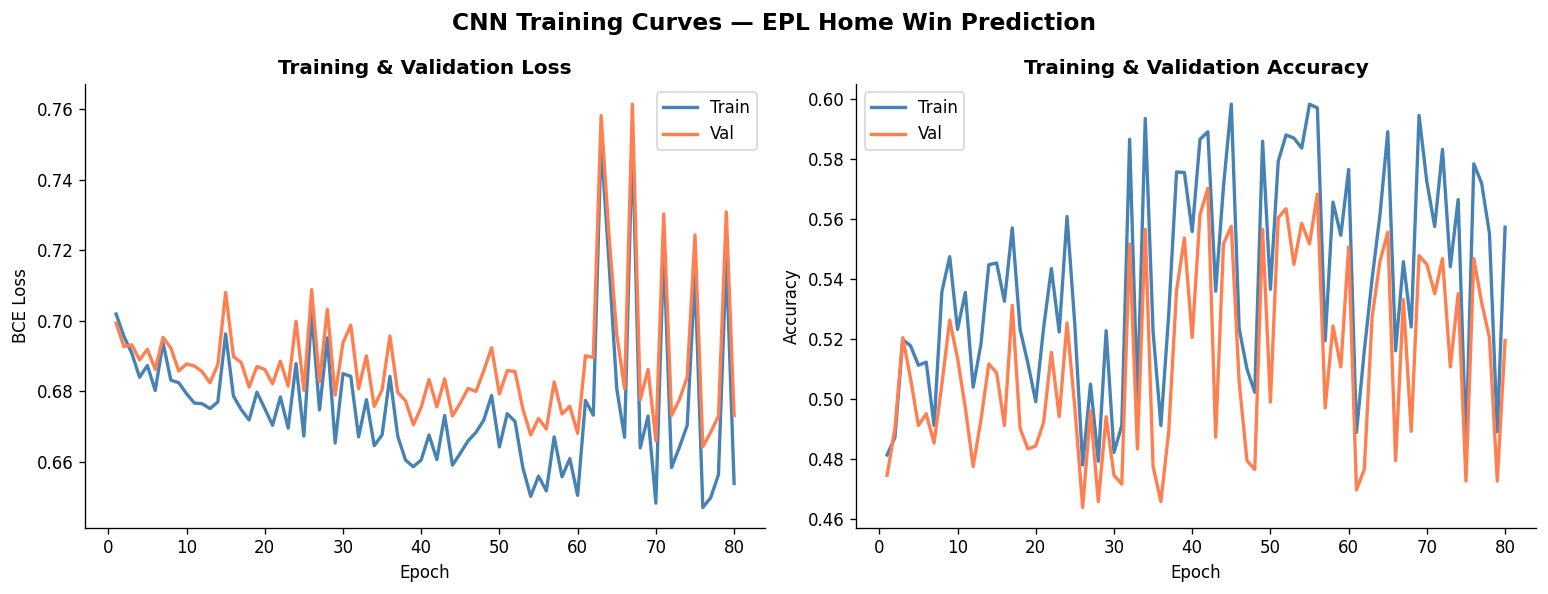

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

epochs_range = range(1, len(train_losses)+1)
axes[0].plot(epochs_range, train_losses, label='Train', color='steelblue', linewidth=2)
axes[0].plot(epochs_range, val_losses,   label='Val',   color='coral',     linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCE Loss')
axes[0].set_title('Training & Validation Loss', fontweight='bold')
axes[0].legend()

axes[1].plot(epochs_range, train_accs, label='Train', color='steelblue', linewidth=2)
axes[1].plot(epochs_range, val_accs,   label='Val',   color='coral',     linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training & Validation Accuracy', fontweight='bold')
axes[1].legend()

plt.suptitle('CNN Training Curves — EPL Home Win Prediction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cnn_training_curves.png', bbox_inches='tight')
plt.show()

## 7. Evaluation Metrics on Test Set

In [8]:
def evaluate(model, X, y, name='Test'):
    y_hat = model.forward(X, training=False)
    y_pred = (y_hat >= 0.5).astype(int)

    tp = np.sum((y_pred==1) & (y==1))
    tn = np.sum((y_pred==0) & (y==0))
    fp = np.sum((y_pred==1) & (y==0))
    fn = np.sum((y_pred==0) & (y==1))

    acc  = (tp+tn)/len(y)
    prec = tp/(tp+fp+1e-9)
    rec  = tp/(tp+fn+1e-9)
    f1   = 2*prec*rec/(prec+rec+1e-9)
    mse  = np.mean((y_hat - y)**2)

    thresholds = np.linspace(0, 1, 200)
    tprs, fprs = [], []
    for t in thresholds:
        pt  = (y_hat >= t).astype(int)
        tpr = np.sum((pt==1) & (y==1)) / (np.sum(y==1)+1e-9)
        fpr = np.sum((pt==1) & (y==0)) / (np.sum(y==0)+1e-9)
        tprs.append(tpr)
        fprs.append(fpr)
    auc = abs(float(np.trapz(tprs[::-1], fprs[::-1])))

    metrics = {
        'accuracy':  round(float(acc),  4),
        'precision': round(float(prec), 4),
        'recall':    round(float(rec),  4),
        'f1':        round(float(f1),   4),
        'auc_roc':   round(auc,         4),
        'mse':       round(float(mse),  6),
        'conf_matrix': [[int(tn), int(fp)], [int(fn), int(tp)]]
    }

    print(f"\n=== {name} Evaluation ===")
    for k, v in metrics.items():
        print(f"  {k}: {v}")

    return metrics, y_hat, fprs, tprs


test_metrics, y_hat_test, fprs_cnn, tprs_cnn = evaluate(model, Xc_test, y_test, 'Test')
val_metrics,  y_hat_val,  _,        _         = evaluate(model, Xc_val,  y_val,  'Val')


=== Test Evaluation ===
  accuracy: 0.6101
  precision: 0.5677
  recall: 0.7137
  f1: 0.6324
  auc_roc: 0.6633
  mse: 0.233852
  conf_matrix: [[282, 262], [138, 344]]

=== Val Evaluation ===
  accuracy: 0.5731
  precision: 0.5312
  recall: 0.6632
  f1: 0.5899
  auc_roc: 0.623
  mse: 0.240336
  conf_matrix: [[273, 278], [160, 315]]


## 8. Visualisations

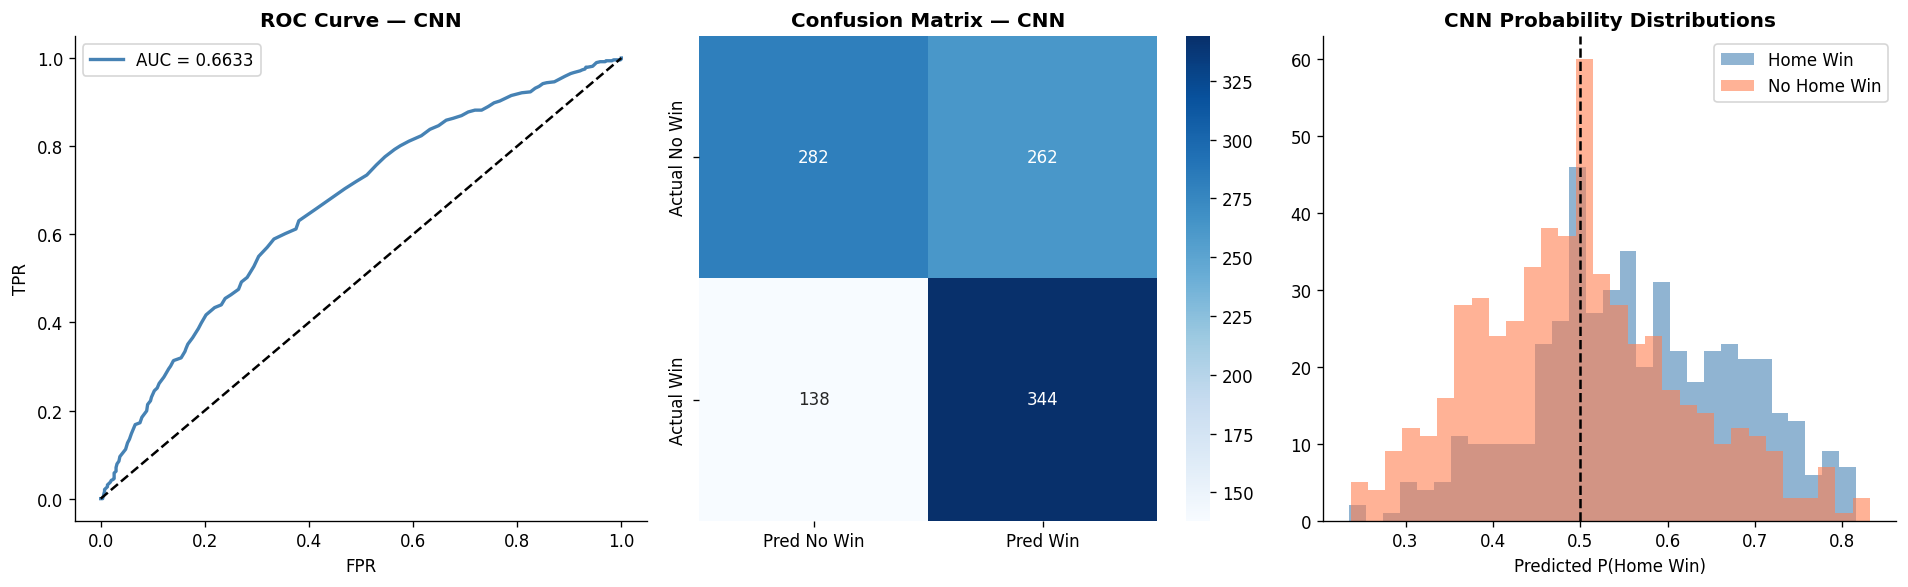

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ROC
axes[0].plot(fprs_cnn[::-1], tprs_cnn[::-1], color='steelblue', linewidth=2,
             label=f"AUC = {test_metrics['auc_roc']:.4f}")
axes[0].plot([0,1],[0,1],'k--')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curve — CNN', fontweight='bold')
axes[0].legend()

# Confusion matrix
cm = np.array(test_metrics['conf_matrix'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Pred No Win','Pred Win'],
            yticklabels=['Actual No Win','Actual Win'])
axes[1].set_title('Confusion Matrix — CNN', fontweight='bold')

# Prediction distribution
axes[2].hist(y_hat_test[y_test==1], bins=30, alpha=0.6, color='steelblue', label='Home Win')
axes[2].hist(y_hat_test[y_test==0], bins=30, alpha=0.6, color='coral',     label='No Home Win')
axes[2].axvline(0.5, color='black', linestyle='--')
axes[2].set_xlabel('Predicted P(Home Win)')
axes[2].set_title('CNN Probability Distributions', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.savefig('cnn_evaluation.png', bbox_inches='tight')
plt.show()

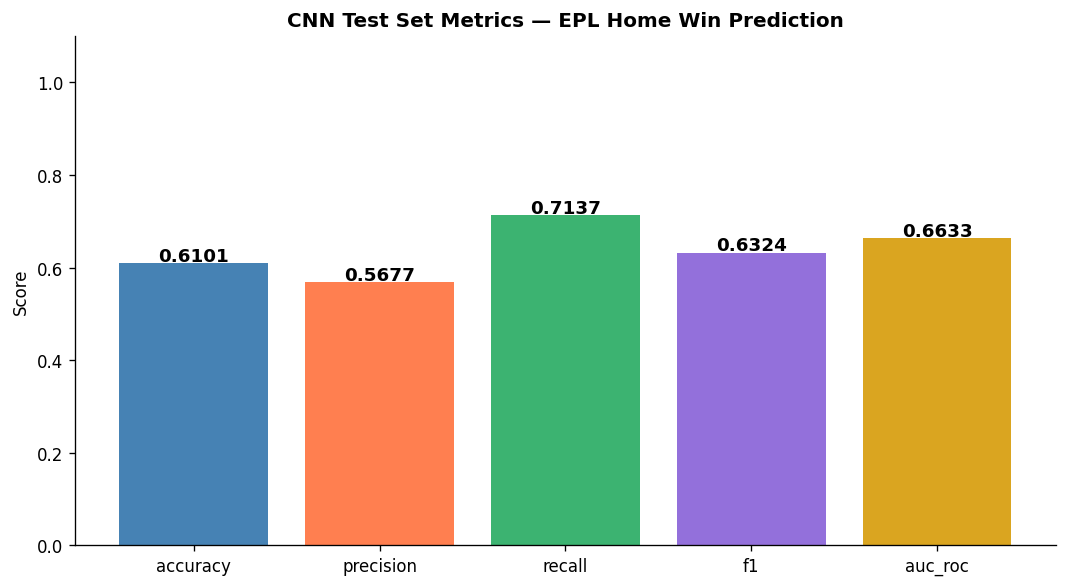

In [10]:
# Metric bar chart
metric_names = ['accuracy', 'precision', 'recall', 'f1', 'auc_roc']
metric_vals  = [test_metrics[m] for m in metric_names]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(metric_names, metric_vals, color=['steelblue','coral','mediumseagreen','mediumpurple','goldenrod'])
for bar, val in zip(bars, metric_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('CNN Test Set Metrics — EPL Home Win Prediction', fontweight='bold')
plt.tight_layout()
plt.savefig('cnn_metrics.png', bbox_inches='tight')
plt.show()

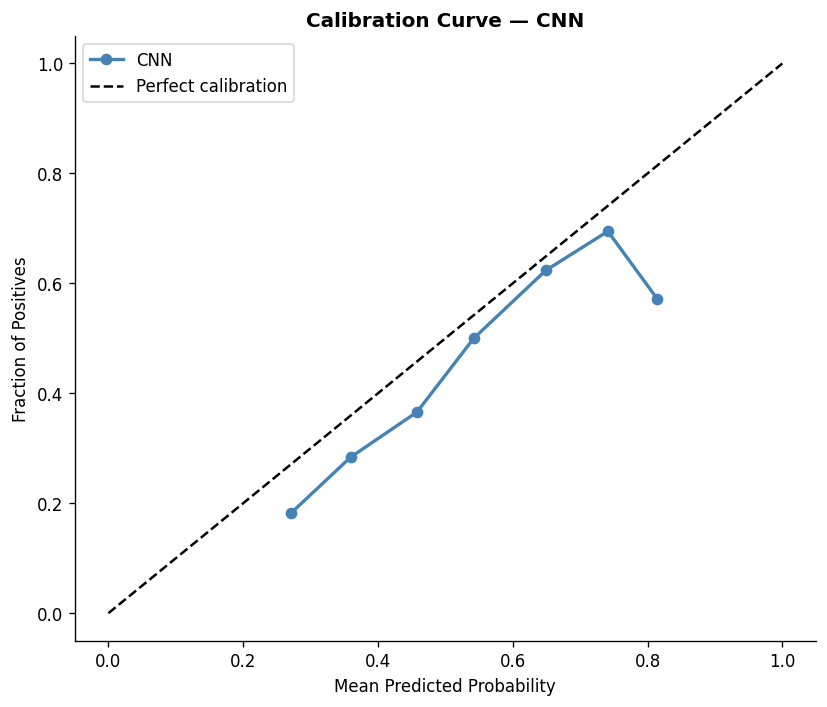

In [11]:
# Calibration curve
bins = np.linspace(0, 1, 11)
bin_means, bin_true = [], []
for i in range(len(bins)-1):
    mask = (y_hat_test >= bins[i]) & (y_hat_test < bins[i+1])
    if mask.sum() > 0:
        bin_means.append(y_hat_test[mask].mean())
        bin_true.append(y_test[mask].mean())

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(bin_means, bin_true, 'o-', color='steelblue', linewidth=2, label='CNN')
ax.plot([0,1],[0,1],'k--', label='Perfect calibration')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Calibration Curve — CNN', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('cnn_calibration.png', bbox_inches='tight')
plt.show()

## 9. Save the Trained Model

In [12]:
# Save model weights as pickle (no PyTorch/TF, so we use pickle)
model_state = {
    'conv1_W': model.conv1.W, 'conv1_b': model.conv1.b,
    'conv2_W': model.conv2.W, 'conv2_b': model.conv2.b,
    'fc1_W':   model.fc1.W,   'fc1_b':   model.fc1.b,
    'fc2_W':   model.fc2.W,   'fc2_b':   model.fc2.b,
    'fc3_W':   model.fc3.W,   'fc3_b':   model.fc3.b,
    'bn1_gamma': model.bn1.gamma, 'bn1_beta': model.bn1.beta,
    'bn1_running_mean': model.bn1.running_mean,
    'bn1_running_var':  model.bn1.running_var,
    'bn2_gamma': model.bn2.gamma, 'bn2_beta': model.bn2.beta,
    'bn2_running_mean': model.bn2.running_mean,
    'bn2_running_var':  model.bn2.running_var,
    'scaler': {'X_min': X_min, 'X_max': X_max, 'X_range': X_range},
    'features': features,
    'teams': teams,
    'team_stats': {},   # will be filled below
}

# Precompute average stats per team for the HTML frontend
stat_cols = ['HTP','ATP','HTFormPts','ATFormPts','HTGD','ATGD',
             'DiffPts','DiffFormPts','HTWinStreak3','HTWinStreak5',
             'ATWinStreak3','ATWinStreak5','HTLossStreak3','ATLossStreak3',
             'HTGS','ATGS','HTGC','ATGC']

for team in teams:
    home_rows = df[df['HomeTeam'] == team]
    away_rows = df[df['AwayTeam'] == team]
    if len(home_rows) == 0:
        continue

    # Use last-season stats (higher match weeks) as representative
    recent_home = home_rows.sort_values('MW').tail(30)
    recent_away = away_rows.sort_values('MW').tail(30)

    model_state['team_stats'][team] = {
        'avg_HTP':          float(recent_home['HTP'].mean()) if len(recent_home) else 0,
        'avg_HTFormPts':    float(recent_home['HTFormPts'].mean()) if len(recent_home) else 0,
        'avg_HTGD':         float(recent_home['HTGD'].mean()) if len(recent_home) else 0,
        'avg_HTGS':         float(recent_home['HTGS'].mean()) if len(recent_home) else 0,
        'avg_HTGC':         float(recent_home['HTGC'].mean()) if len(recent_home) else 0,
        'avg_HTWinStreak3': float(recent_home['HTWinStreak3'].mean()) if len(recent_home) else 0,
        'avg_HTLossStreak3':float(recent_home['HTLossStreak3'].mean()) if len(recent_home) else 0,
        'avg_ATP':          float(recent_away['ATP'].mean()) if len(recent_away) else 0,
        'avg_ATFormPts':    float(recent_away['ATFormPts'].mean()) if len(recent_away) else 0,
        'avg_ATGD':         float(recent_away['ATGD'].mean()) if len(recent_away) else 0,
        'avg_ATGS':         float(recent_away['ATGS'].mean()) if len(recent_away) else 0,
        'avg_ATGC':         float(recent_away['ATGC'].mean()) if len(recent_away) else 0,
        'avg_ATWinStreak3': float(recent_away['ATWinStreak3'].mean()) if len(recent_away) else 0,
        'avg_ATLossStreak3':float(recent_away['ATLossStreak3'].mean()) if len(recent_away) else 0,
        'home_win_rate':    float((recent_home['FTR']=='H').mean()) if len(recent_home) else 0.46,
        'away_win_rate':    float((recent_away['FTR']=='NH').mean()) if len(recent_away) else 0.54,
    }

with open('epl_cnn_model.pkl', 'wb') as f:
    pickle.dump(model_state, f)

print("Model saved to epl_cnn_model.pkl")
print(f"Teams saved: {len(model_state['team_stats'])}")

Model saved to epl_cnn_model.pkl
Teams saved: 44


## 10. Save Results to JSON

In [13]:
cnn_results = {
    'model': 'CNN from Scratch (NumPy only)',
    'architecture': 'Conv1D(1→16,k=3) → Conv1D(16→32,k=3) → GlobalAvgPool → FC(64) → FC(32) → FC(1)',
    'dataset': 'EPL 2000-2019',
    'n_samples': int(data.shape[0]),
    'train_size': int(X_train.shape[0]),
    'val_size':   int(X_val.shape[0]),
    'test_size':  int(X_test.shape[0]),
    'epochs': len(train_losses),
    'final_train_loss': round(train_losses[-1], 4),
    'final_val_loss':   round(val_losses[-1],   4),
    'test_evaluation': {
        'accuracy':  test_metrics['accuracy'],
        'precision': test_metrics['precision'],
        'recall':    test_metrics['recall'],
        'f1':        test_metrics['f1'],
        'auc_roc':   test_metrics['auc_roc'],
        'mse':       test_metrics['mse'],
        'conf_matrix': test_metrics['conf_matrix'],
        # These are the metrics comparable to the logistic regression results.json
        'comparable_metrics': {
            'accuracy':  test_metrics['accuracy'],
            'f1':        test_metrics['f1'],
            'auc_roc':   test_metrics['auc_roc'],
            'precision': test_metrics['precision'],
            'recall':    test_metrics['recall'],
        }
    }
}

with open('cnn_results.json', 'w') as f:
    json.dump(cnn_results, f, indent=2)

print("Results saved to cnn_results.json")
print(json.dumps(cnn_results, indent=2))

Results saved to cnn_results.json
{
  "model": "CNN from Scratch (NumPy only)",
  "architecture": "Conv1D(1\u219216,k=3) \u2192 Conv1D(16\u219232,k=3) \u2192 GlobalAvgPool \u2192 FC(64) \u2192 FC(32) \u2192 FC(1)",
  "dataset": "EPL 2000-2019",
  "n_samples": 6840,
  "train_size": 4788,
  "val_size": 1026,
  "test_size": 1026,
  "epochs": 80,
  "final_train_loss": 0.6539,
  "final_val_loss": 0.6732,
  "test_evaluation": {
    "accuracy": 0.6101,
    "precision": 0.5677,
    "recall": 0.7137,
    "f1": 0.6324,
    "auc_roc": 0.6633,
    "mse": 0.233852,
    "conf_matrix": [
      [
        282,
        262
      ],
      [
        138,
        344
      ]
    ],
    "comparable_metrics": {
      "accuracy": 0.6101,
      "f1": 0.6324,
      "auc_roc": 0.6633,
      "precision": 0.5677,
      "recall": 0.7137
    }
  }
}


## 11. Final Comparison — CNN vs Logistic Regression
Load the regression results JSON if available and compare side by side.

In [14]:
import os

cnn_comp = cnn_results['test_evaluation']['comparable_metrics']

if os.path.exists('regression_results.json'):
    with open('regression_results.json') as f:
        reg_data = json.load(f)
    reg_comp = reg_data['logistic_regression']['comparable_metrics']
    has_reg = True
else:
    # Placeholder if regression notebook hasn't been run
    reg_comp = {'accuracy': None, 'f1': None, 'auc_roc': None, 'precision': None, 'recall': None}
    has_reg = False

print("=" * 55)
print("MODEL COMPARISON: CNN vs Logistic Regression")
print("=" * 55)
print(f"{'Metric':<15} {'CNN':>12} {'Logistic Reg':>15}")
print("-" * 55)
for metric in ['accuracy', 'f1', 'auc_roc', 'precision', 'recall']:
    cnn_v = cnn_comp[metric]
    reg_v = reg_comp[metric]
    reg_str = f"{reg_v:.4f}" if reg_v is not None else 'N/A'
    winner = ''
    if reg_v is not None:
        winner = ' ← CNN wins' if cnn_v > reg_v else ' ← LogReg wins'
    print(f"{metric:<15} {cnn_v:>12.4f} {reg_str:>15}{winner}")

if not has_reg:
    print("\n[Run epl_regression.ipynb first to get logistic regression results for comparison]")

MODEL COMPARISON: CNN vs Logistic Regression
Metric                   CNN    Logistic Reg
-------------------------------------------------------
accuracy              0.6101             N/A
f1                    0.6324             N/A
auc_roc               0.6633             N/A
precision             0.5677             N/A
recall                0.7137             N/A

[Run epl_regression.ipynb first to get logistic regression results for comparison]


In [15]:
if has_reg:
    metrics_to_plot = ['accuracy', 'f1', 'auc_roc', 'precision', 'recall']
    cnn_vals = [cnn_comp[m] for m in metrics_to_plot]
    reg_vals = [reg_comp[m] for m in metrics_to_plot]

    x = np.arange(len(metrics_to_plot))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    bars1 = ax.bar(x - width/2, cnn_vals, width, label='CNN', color='steelblue', alpha=0.85)
    bars2 = ax.bar(x + width/2, reg_vals, width, label='Logistic Regression', color='coral', alpha=0.85)

    for bar in bars1:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{bar.get_height():.3f}', ha='center', fontsize=9)
    for bar in bars2:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{bar.get_height():.3f}', ha='center', fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(metrics_to_plot)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Score')
    ax.set_title('CNN vs Logistic Regression — Test Set Comparison', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.savefig('model_comparison.png', bbox_inches='tight')
    plt.show()
else:
    print("Run regression notebook first for the comparison plot.")

Run regression notebook first for the comparison plot.
